In [16]:
import numpy as np

sizes = [3 * (2**i) for i in range(8)]  # [3,6,12,...,384]

matrices = []
for n in sizes:
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    matrices.append((A, B))

In [17]:
def naive(A, B):
    n = len(A)
    result = [[0 for _ in range(n)] for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            for k in range(n):
                result[i][j] += A[i][k] * B[k][j]
                
    return result

In [18]:
import time

naive_times = []
numpy_times = []

for A, B in matrices:
    n = len(A)
    
    A_list = A.tolist()
    B_list = B.tolist()
    
    # ---- Naive ----
    start = time.time()
    naive(A_list, B_list)
    end = time.time()
    naive_times.append(end - start)
    
    # ---- NumPy ----
    start = time.time()
    np.dot(A, B)
    end = time.time()
    numpy_times.append(end - start)

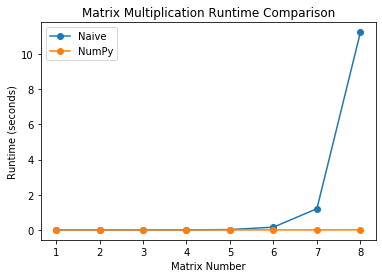

In [19]:
import matplotlib.pyplot as plt

x = list(range(1, 9))  # matrix number

plt.plot(x, naive_times, marker='o', label='Naive')
plt.plot(x, numpy_times, marker='o', label='NumPy')

plt.xlabel("Matrix Number")
plt.ylabel("Runtime (seconds)")
plt.title("Matrix Multiplication Runtime Comparison")
plt.legend()

plt.show()